<a href="https://colab.research.google.com/github/project-ida/arpa-e-experiments/blob/main/templates/eds-sample-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<a href="https://nbviewer.org/github/project-ida/arpa-e-experiments/blob/main/templates/eds-sample-analysis.ipynb" target="_parent"><img src="https://nbviewer.org/static/img/nav_logo.svg" alt="Open In nbviewer" width="100"/></a>

# Surface Viewer EDS Analysis Template

This notebook provides an end-to-end workflow for EDS analysis using data from the Surface Viewer. It can load one or more saved ROI selections, optionally pull the full mosaic cell grid from `selection-grid.json`, retrieve the corresponding cell spectra, and generate cumulative spectra for both selected regions and the full sample.

It also supports basic spectral conditioning and first-pass peak/element identification, comparison of band-sum distributions across regions, overlay plots of individual cell spectra with annotated element lines, and creation of heatmap overlay files for visualization back in the Surface Viewer.

## How to use

1. Add one or more ROI API links to `ROI_API_URLS`.
2. Decide whether to include the full mosaic by setting `LOAD_ALL_CELLS = True` or `False`.
3. Run the notebook from top to bottom to load spectra, generate cumulative plots, and inspect the peak-identification results.
4. Define a spectral band in either channels or keV for band-sum histograms and overlay generation.
5. Review the histogram-based range suggestions and, if desired, create a new overlay heatmap file for the sample.
6. Open the printed sample link in the Surface Viewer to inspect the generated overlay in context.


In [25]:
# Set up the GitHub repo in Colab so the shared helper modules can be imported.

!pip install colocal -q
import colocal
root, branch, cwd = colocal.setup("https://github.com/project-ida/arpa-e-experiments")

[Colab] Repo: arpa-e-experiments | Branch: None
[Colab] Repo root added to sys.path
[Colab] Working directory set to: .


In [26]:
# Import Python libraries, URL helpers, and reusable Surface Viewer analysis modules.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from urllib.parse import urlparse, parse_qs, quote_plus

from libs.surface_viewer.io import (
    get_roi_name_from_api_url,
    load_roi_api,
    add_json_urls,
    load_all_cells_from_selection_grid,
    build_spectrum_index,
    attach_spectra,
)

from libs.surface_viewer.spectra import (
    stack_spectra_trim,
    band_sum,
    summarize_band_values,
    resolve_band_to_channels,
    band_label_text,
)

from libs.surface_viewer.calibration import (
    maybe_get_calibration,
    channel_to_keV,
    make_energy_axis,
)

from libs.surface_viewer.peaks import (
    baseline_als,
    preprocess,
    detect_peaks,
    identify_elements,
)

from libs.surface_viewer.plotting import (
    add_energy_top_axis,
    plot_cumulative,
    plot_overlay,
    plot_with_peaks,
    plot_identified_elements_confident,
    plot_overlaid_cell_spectra,
)

from libs.surface_viewer.overlays import (
    get_api_auth,
    create_overlay,
    delete_overlay,
)

In [27]:
# Define ROI URLs and the main analysis parameters for loading, calibration, and peak finding.

ROI_API_URLS = [
    "https://nucleonics.mit.edu/surface-viewer/api/rois.php?dataset=JPB2_Pd-TF-12_EDS_post%20(20250826%20%23%2010%20after%20(eds))&name=adhesive-paste",
    "https://nucleonics.mit.edu/surface-viewer/api/rois.php?dataset=JPB2_Pd-TF-12_EDS_post%20(20250826%20%23%2010%20after%20(eds))&name=margin",
    "https://nucleonics.mit.edu/surface-viewer/api/rois.php?dataset=JPB2_Pd-TF-12_EDS_post%20(20250826%20%23%2010%20after%20(eds))&name=sample-corner"
]

# General display / loading behavior
LOAD_ALL_CELLS = True
SHOW_ENERGY_TOP_AXIS = True
ALLOW_DEFAULT_CALIBRATION = True

# Peak-analysis knobs
PEAK_MAX_PEAKS = 6
PEAK_TOP_N_LABELS = 6
PEAK_BEAM_KEV = 15.0
PEAK_FWHM_MN_EV = 67.8


## 1. Load ROI selections and, optionally, the full mosaic cell grid


In [28]:
# Load ROI selections and, if requested, enumerate all cells from overlays/selection-grid.json.

roi_frames = {}
all_cells_df = pd.DataFrame()

for api_url in ROI_API_URLS:
    roi_name = get_roi_name_from_api_url(api_url)
    df = load_roi_api(api_url)
    df = add_json_urls(df, api_url)
    df["roi_name"] = roi_name
    roi_frames[roi_name] = df

    print(f"{roi_name}: {len(df)} selected cells")
    if not df.empty:
        display(df.head())

if LOAD_ALL_CELLS:
    all_cells_df = load_all_cells_from_selection_grid(ROI_API_URLS[0])
    print(f"all-cells: {len(all_cells_df)} cells enumerated from overlays/selection-grid.json")
    if not all_cells_df.empty:
        display(all_cells_df.head())


adhesive-paste: 17 selected cells


,col,row,srcJson,basename,foldername,json_url,roi_name
0,2,0,aggregated-spectra/Project 1 Specimen 1 Area 1...,Project 1 Specimen 1 Area 1 Site 429 Map Data 428,aggregated-spectra,https://nucleonics.mit.edu/surface-viewer/data...,adhesive-paste
1,2,2,aggregated-spectra/Project 1 Specimen 1 Area 1...,Project 1 Specimen 1 Area 1 Site 410 Map Data 409,aggregated-spectra,https://nucleonics.mit.edu/surface-viewer/data...,adhesive-paste
2,1,2,aggregated-spectra/Project 1 Specimen 1 Area 1...,Project 1 Specimen 1 Area 1 Site 410 Map Data 409,aggregated-spectra,https://nucleonics.mit.edu/surface-viewer/data...,adhesive-paste
3,1,1,aggregated-spectra/Project 1 Specimen 1 Area 1...,Project 1 Specimen 1 Area 1 Site 410 Map Data 409,aggregated-spectra,https://nucleonics.mit.edu/surface-viewer/data...,adhesive-paste
4,1,0,aggregated-spectra/Project 1 Specimen 1 Area 1...,Project 1 Specimen 1 Area 1 Site 410 Map Data 409,aggregated-spectra,https://nucleonics.mit.edu/surface-viewer/data...,adhesive-paste


margin: 34 selected cells


,col,row,srcJson,basename,foldername,json_url,roi_name
0,0,0,aggregated-spectra/Project 1 Specimen 1 Area 1...,Project 1 Specimen 1 Area 1 Site 8 Map Data 7,aggregated-spectra,https://nucleonics.mit.edu/surface-viewer/data...,margin
1,1,0,aggregated-spectra/Project 1 Specimen 1 Area 1...,Project 1 Specimen 1 Area 1 Site 8 Map Data 7,aggregated-spectra,https://nucleonics.mit.edu/surface-viewer/data...,margin
2,2,0,aggregated-spectra/Project 1 Specimen 1 Area 1...,Project 1 Specimen 1 Area 1 Site 8 Map Data 7,aggregated-spectra,https://nucleonics.mit.edu/surface-viewer/data...,margin
3,0,0,aggregated-spectra/Project 1 Specimen 1 Area 1...,Project 1 Specimen 1 Area 1 Site 7 Map Data 6,aggregated-spectra,https://nucleonics.mit.edu/surface-viewer/data...,margin
4,0,1,aggregated-spectra/Project 1 Specimen 1 Area 1...,Project 1 Specimen 1 Area 1 Site 8 Map Data 7,aggregated-spectra,https://nucleonics.mit.edu/surface-viewer/data...,margin


sample-corner: 25 selected cells


,col,row,srcJson,basename,foldername,json_url,roi_name
0,1,1,aggregated-spectra/Project 1 Specimen 1 Area 1...,Project 1 Specimen 1 Area 1 Site 49 Map Data 48,aggregated-spectra,https://nucleonics.mit.edu/surface-viewer/data...,sample-corner
1,2,1,aggregated-spectra/Project 1 Specimen 1 Area 1...,Project 1 Specimen 1 Area 1 Site 49 Map Data 48,aggregated-spectra,https://nucleonics.mit.edu/surface-viewer/data...,sample-corner
2,0,1,aggregated-spectra/Project 1 Specimen 1 Area 1...,Project 1 Specimen 1 Area 1 Site 48 Map Data 47,aggregated-spectra,https://nucleonics.mit.edu/surface-viewer/data...,sample-corner
3,1,1,aggregated-spectra/Project 1 Specimen 1 Area 1...,Project 1 Specimen 1 Area 1 Site 48 Map Data 47,aggregated-spectra,https://nucleonics.mit.edu/surface-viewer/data...,sample-corner
4,2,1,aggregated-spectra/Project 1 Specimen 1 Area 1...,Project 1 Specimen 1 Area 1 Site 48 Map Data 47,aggregated-spectra,https://nucleonics.mit.edu/surface-viewer/data...,sample-corner


all-cells: 3861 cells enumerated from overlays/selection-grid.json


,row,col,srcJson,basename,label,x,y,width,height,json_url
0,0,0,aggregated-spectra/Project 1 Specimen 1 Area 1...,Project 1 Specimen 1 Area 1 Site 10 Map Data 9,Project 1 Specimen 1 Area 1 Site 10 Map Data 9...,9207.819603,380.083993,181.153251,135.864939,https://nucleonics.mit.edu/surface-viewer/data...
1,0,1,aggregated-spectra/Project 1 Specimen 1 Area 1...,Project 1 Specimen 1 Area 1 Site 10 Map Data 9,Project 1 Specimen 1 Area 1 Site 10 Map Data 9...,9388.972855,380.083993,181.153251,135.864939,https://nucleonics.mit.edu/surface-viewer/data...
2,0,2,aggregated-spectra/Project 1 Specimen 1 Area 1...,Project 1 Specimen 1 Area 1 Site 10 Map Data 9,Project 1 Specimen 1 Area 1 Site 10 Map Data 9...,9570.126106,380.083993,181.153251,135.864939,https://nucleonics.mit.edu/surface-viewer/data...
3,1,0,aggregated-spectra/Project 1 Specimen 1 Area 1...,Project 1 Specimen 1 Area 1 Site 10 Map Data 9,Project 1 Specimen 1 Area 1 Site 10 Map Data 9...,9207.819603,515.948932,181.153251,135.864939,https://nucleonics.mit.edu/surface-viewer/data...
4,1,1,aggregated-spectra/Project 1 Specimen 1 Area 1...,Project 1 Specimen 1 Area 1 Site 10 Map Data 9,Project 1 Specimen 1 Area 1 Site 10 Map Data 9...,9388.972855,515.948932,181.153251,135.864939,https://nucleonics.mit.edu/surface-viewer/data...


In [29]:
# Collect the unique spectrum JSON URLs needed across ROI selections and the all-cells grid.

roi_urls = sorted(set(
    url
    for df in roi_frames.values()
    for url in df["json_url"].dropna().unique().tolist()
))

all_cell_urls = []
if LOAD_ALL_CELLS and not all_cells_df.empty:
    all_cell_urls = sorted(all_cells_df["json_url"].dropna().unique().tolist())

all_urls = sorted(set(roi_urls) | set(all_cell_urls))

print(f"Will download {len(all_urls)} unique JSON file(s) across ROI sets and the all-cells grid")
index = build_spectrum_index(all_urls, progress=True)


Will download 429 unique JSON file(s) across ROI sets and the all-cells grid


In [30]:
# Attach spectra to the ROI tables and the optional all-cells table.

for roi_name, df in roi_frames.items():
    roi_frames[roi_name] = attach_spectra(df, index, progress=True)

    ok = roi_frames[roi_name]["spectrum"].notna().sum()
    print(f"{roi_name}: spectra attached for {ok} / {len(roi_frames[roi_name])} selections")

if LOAD_ALL_CELLS and not all_cells_df.empty:
    all_cells_df = attach_spectra(all_cells_df, index, progress=True)
    ok_all = all_cells_df["spectrum"].notna().sum()
    print(f"all-cells: spectra attached for {ok_all} / {len(all_cells_df)} cells")


Indexing spectra: 100%|██████████| 17/17 [00:00<00:00, 8238.38it/s]


adhesive-paste: spectra attached for 17 / 17 selections


Indexing spectra: 100%|██████████| 34/34 [00:00<00:00, 14150.26it/s]


margin: spectra attached for 34 / 34 selections


Indexing spectra: 100%|██████████| 25/25 [00:00<00:00, 13742.80it/s]


sample-corner: spectra attached for 25 / 25 selections


Indexing spectra: 100%|██████████| 3861/3861 [00:00<00:00, 79358.86it/s]

all-cells: spectra attached for 3861 / 3861 cells


In [31]:
# Print quick summaries of the selected ROI cells by basename and source spectrum file.

for roi_name, df in roi_frames.items():
    print(f"\n=== {roi_name} ===")
    if df.empty:
        print("No selections")
        continue

    print(f"Selected cells: {len(df)}")
    if "basename" in df.columns:
        print(f"Unique basenames: {df['basename'].nunique()}")
    if "srcJson" in df.columns:
        print(f"Unique spectrum JSON files: {df['srcJson'].nunique()}")

    display(df.groupby("basename", dropna=False).size().sort_values(ascending=False).to_frame("n_selected").head(20))

if LOAD_ALL_CELLS and not all_cells_df.empty:
    print("\n=== all-cells ===")
    print(f"Cells in full mosaic: {len(all_cells_df)}")
    if "basename" in all_cells_df.columns:
        print(f"Unique basenames: {all_cells_df['basename'].nunique()}")
    if "srcJson" in all_cells_df.columns:
        print(f"Unique spectrum JSON files: {all_cells_df['srcJson'].nunique()}")



=== adhesive-paste ===
Selected cells: 17
Unique basenames: 5
Unique spectrum JSON files: 5


,n_selected
basename,
Project 1 Specimen 1 Area 1 Site 410 Map Data 409,6
Project 1 Specimen 1 Area 1 Site 429 Map Data 428,6
Project 1 Specimen 1 Area 1 Site 428 Map Data 427,3
Project 1 Specimen 1 Area 1 Site 391 Map Data 390,1
Project 1 Specimen 1 Area 1 Site 409 Map Data 408,1



=== margin ===
Selected cells: 34
Unique basenames: 6
Unique spectrum JSON files: 6


,n_selected
basename,
Project 1 Specimen 1 Area 1 Site 2 Map Data 1,6
Project 1 Specimen 1 Area 1 Site 3 Map Data 2,6
Project 1 Specimen 1 Area 1 Site 4 Map Data 3,6
Project 1 Specimen 1 Area 1 Site 8 Map Data 7,6
Project 1 Specimen 1 Area 1 Site 5 Map Data 4,5
Project 1 Specimen 1 Area 1 Site 7 Map Data 6,5



=== sample-corner ===
Selected cells: 25
Unique basenames: 4
Unique spectrum JSON files: 4


,n_selected
basename,
Project 1 Specimen 1 Area 1 Site 66 Map Data 65,9
Project 1 Specimen 1 Area 1 Site 48 Map Data 47,6
Project 1 Specimen 1 Area 1 Site 67 Map Data 66,6
Project 1 Specimen 1 Area 1 Site 49 Map Data 48,4



=== all-cells ===
Cells in full mosaic: 3861
Unique basenames: 429
Unique spectrum JSON files: 429


*Step 2: Build aggregate spectra for all cells and each ROI region.*

## 2. Build aggregate spectra for all cells and for each ROI region


In [32]:
# Build aggregate stacks, cumulative spectra, and mean spectra for each analysis group.

need_calibration = True
cal = maybe_get_calibration(
    ROI_API_URLS,
    need_calibration=need_calibration,
    allow_defaults=ALLOW_DEFAULT_CALIBRATION,
)

roi_results = {}
for api_url in ROI_API_URLS:
    roi_name = get_roi_name_from_api_url(api_url)
    df = roi_frames[roi_name]
    df_ok = df[df["spectrum"].notna()].copy()

    if df_ok.empty:
        print(f"{roi_name}: no spectra available")
        continue

    stack, x = stack_spectra_trim(df_ok["spectrum"])
    roi_results[roi_name] = {
        "label": roi_name,
        "api_url": api_url,
        "df": df_ok,
        "stack": stack,
        "x": x,
        "cumulative": stack.sum(axis=0),
        "mean_spectrum": stack.mean(axis=0),
    }
    print(f"{roi_name}: {stack.shape[0]} spectra, common length {stack.shape[1]}")

all_cells_result = None
if LOAD_ALL_CELLS and not all_cells_df.empty:
    df_all_ok = all_cells_df[all_cells_df["spectrum"].notna()].copy()
    if not df_all_ok.empty:
        stack_all, x_all = stack_spectra_trim(df_all_ok["spectrum"])
        all_cells_result = {
            "label": "all-cells",
            "api_url": ROI_API_URLS[0],
            "df": df_all_ok,
            "stack": stack_all,
            "x": x_all,
            "cumulative": stack_all.sum(axis=0),
            "mean_spectrum": stack_all.mean(axis=0),
        }
        print(f"all-cells: {stack_all.shape[0]} spectra, common length {stack_all.shape[1]}")

aggregate_results = {}
if all_cells_result is not None:
    aggregate_results["all-cells"] = all_cells_result
for api_url in ROI_API_URLS:
    roi_name = get_roi_name_from_api_url(api_url)
    if roi_name in roi_results:
        aggregate_results[roi_name] = roi_results[roi_name]


adhesive-paste: 17 spectra, common length 2048
margin: 34 spectra, common length 2048
sample-corner: 25 spectra, common length 2048
all-cells: 3861 spectra, common length 2048


In [33]:
# Report which energy calibration was found and whether config values or defaults are being used.

if cal is not None:
    source_text = "config.txt" if cal.get("from_config") else "defaults"
    print(f"Energy calibration source: {source_text}")
    print("Calibration:", cal)
else:
    print("No energy calibration available; top energy axis will be omitted.")


Energy calibration source: config.txt
Calibration: {'dataset_base': 'https://nucleonics.mit.edu/surface-viewer/data/JPB2_Pd-TF-12_EDS_post%20%2820250826%20%23%2010%20after%20%28eds%29%29/', 'eV_per_ch': 9.998198509216309, 'start_eV': -197.37855529785156, 'n_channels': 2048, 'raw_cfg': {'um_per_px': '0.6100110411643982', 'shift_x_px': '1195.35', 'shift_y_px': '579.99', 'rotation': '1.15', 'scale': '1*0.96669', 'total_width_px': '17637', 'total_height_px': '16698', 'eds_ev_per_ch': '9.998198509216309', 'eds_start_ev': '-197.37855529785156', 'eds_n_channels': '2048', 'expected_elements': 'Pd,Cr,Si,Al,O', 'sought_elements': 'Fe,Mn,Zn,Ni'}, 'from_config': True}


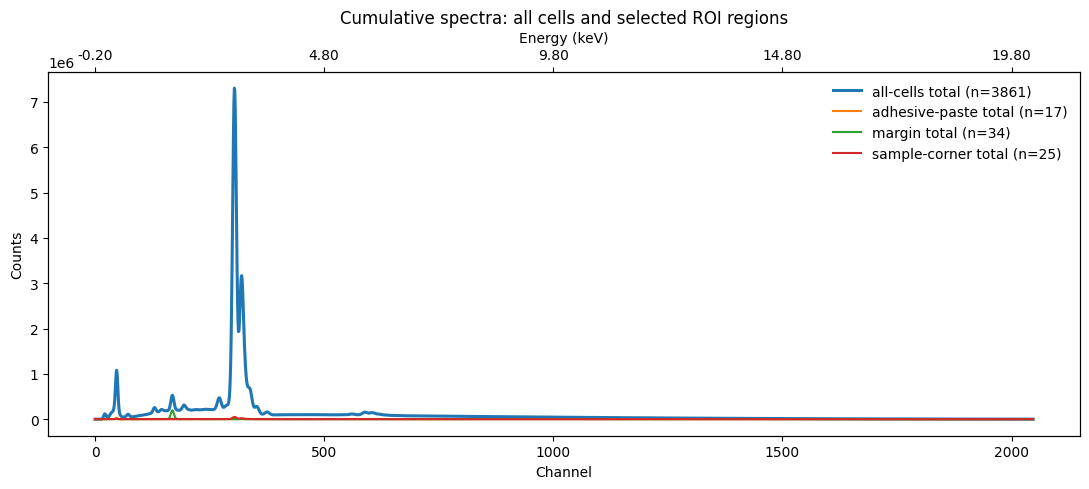

In [34]:
# Plot cumulative spectra for all cells and ROI regions on a common axis.

fig, ax = plt.subplots(figsize=(11, 5))

for name, res in aggregate_results.items():
    y = res["cumulative"]
    x_plot = np.arange(len(y))
    lw = 2.2 if name == "all-cells" else 1.5
    ax.plot(x_plot, y, label=f"{name} total (n={res['stack'].shape[0]})", lw=lw)

ax.set_xlabel("Channel")
ax.set_ylabel("Counts")
ax.set_title("Cumulative spectra: all cells and selected ROI regions")

if SHOW_ENERGY_TOP_AXIS and cal is not None:
    max_len = max(len(res["cumulative"]) for res in aggregate_results.values())
    add_energy_top_axis(ax, cal=cal, n=max_len)

ax.legend(frameon=False)
fig.tight_layout()
plt.show()


*Step 2b: Run basic conditioning and first-pass element identification on the aggregate spectra.*

### Basic conditioning and peak identification on the aggregate spectra



=== all-cells: cumulative spectrum ===


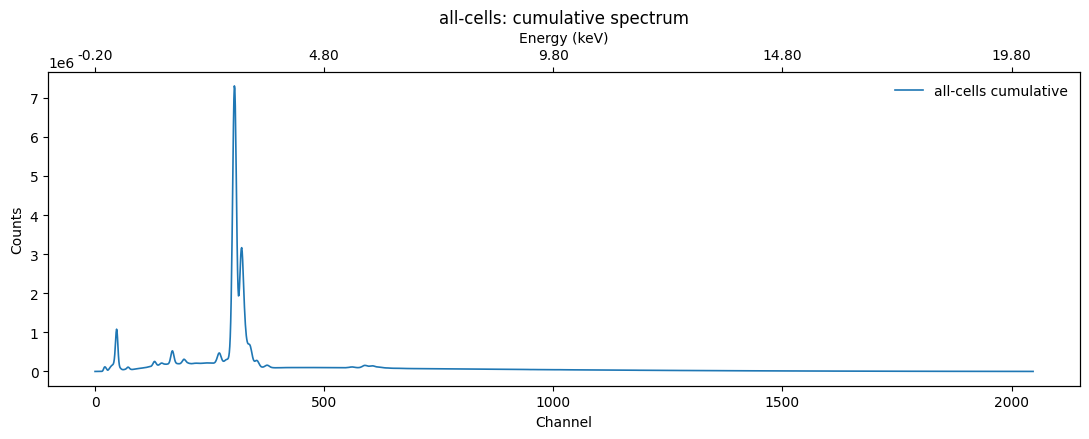

/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


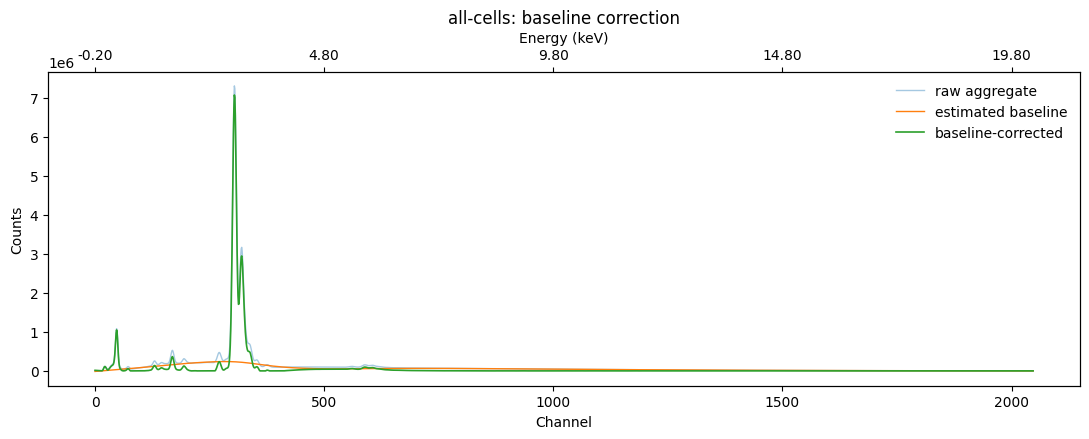

Noise estimate: 23.024339003833212
min_prom: 138.1460340229993
min_height: 69.07301701149964


/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


,x,idx,height,prominence,fwhm,area
0,47.0,47,7.092458e+05,6.992781e+05,12.187573,7.428215e+06
1,130.0,130,1.042804e+05,7.819289e+04,11.477729,1.064671e+06
2,169.0,169,2.817711e+05,2.817711e+05,12.515145,2.951718e+06
3,271.0,271,1.952183e+05,1.952183e+05,12.079770,2.001767e+06
4,304.0,304,5.917678e+06,5.917678e+06,13.667254,6.613603e+07
5,321.0,321,2.463413e+06,3.027567e+05,4.754899,1.429994e+07


/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


,energy_keV,idx,height,prominence,area,fwhm,element,line,lib_energy_keV,delta_keV,label
0,0.272537,47,7.092458e+05,6.992781e+05,74268.765816,12.187573,C,Ka1,0.2770,0.004463,C Ka1
1,1.102387,130,1.042804e+05,7.819289e+04,10644.792729,11.477729,Na,Ka1,1.0403,-0.062087,Na Ka1
2,1.492317,169,2.817711e+05,2.817711e+05,29511.864120,12.515145,Al,Ka1,1.4865,-0.005817,Al Ka1
3,2.512133,271,1.952183e+05,1.952183e+05,20014.061821,12.079770,S,Kb1,2.4650,-0.047133,S Kb1
4,2.842074,304,5.917678e+06,5.917678e+06,661241.114313,13.667254,Pd,La1,2.8378,-0.004274,Pd La1
5,3.012043,321,2.463413e+06,3.027567e+05,142973.644906,4.754899,Pd,Lb1,2.9895,-0.022543,Pd Lb1


/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


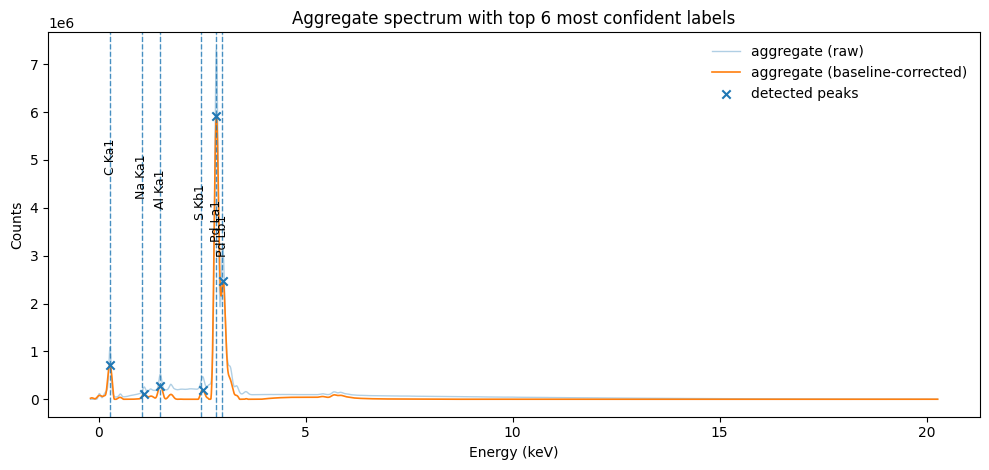


=== adhesive-paste: cumulative spectrum ===


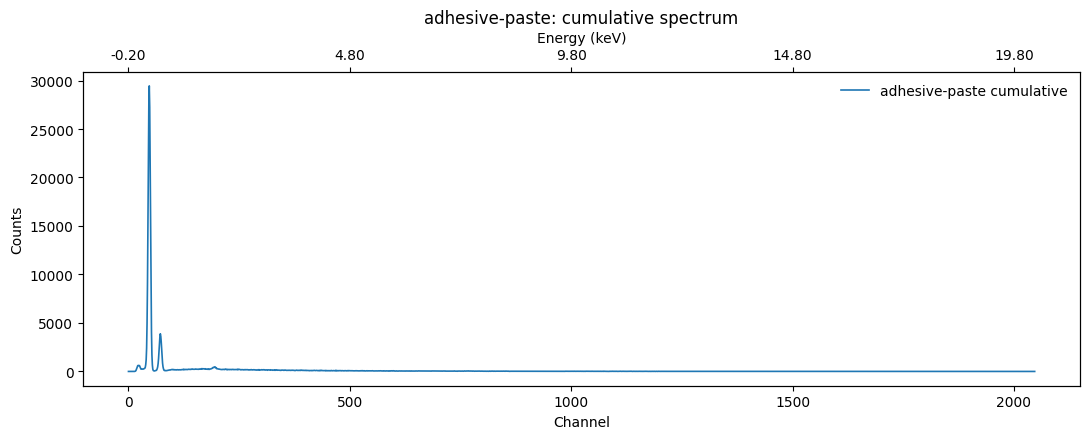

/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


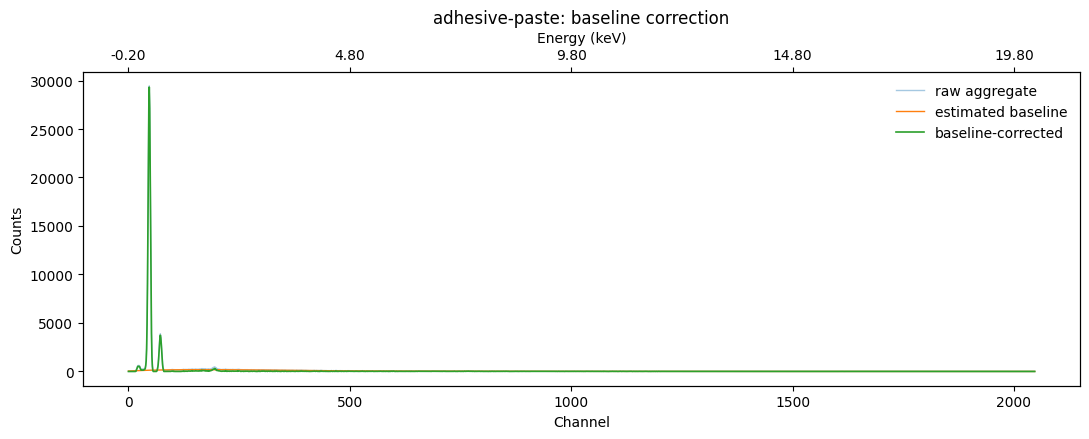

Noise estimate: 0.386220062734685
min_prom: 2.31732037640811
min_height: 1.158660188204055


/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


,x,idx,height,prominence,fwhm,area
0,3.0,3,765.309104,46.951604,5.167988,5253.788632
1,24.0,24,1166.542386,483.752983,12.416980,13985.402457
2,47.0,47,18880.327560,18880.327560,11.482833,183717.821516
3,72.0,72,3063.839480,3063.839480,12.775682,33867.859666
4,97.0,97,552.078453,192.276929,37.653779,19504.674470
5,193.0,193,438.857953,145.147061,10.896252,4534.427863


/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


,energy_keV,idx,height,prominence,area,fwhm,element,line,lib_energy_keV,delta_keV,label
0,0.272537,47,18880.327560,18880.327560,1836.847249,11.482833,C,Ka1,0.2770,0.004463,C Ka1
1,0.522492,72,3063.839480,3063.839480,338.617584,12.775682,O,Ka1,0.5249,0.002408,O Ka1
2,0.772447,97,552.078453,192.276929,195.011607,37.653779,Co,La1,0.7751,0.002653,Co La1
3,1.732274,193,438.857953,145.147061,45.336110,10.896252,Si,Ka1,1.7398,0.007526,Si Ka1


/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


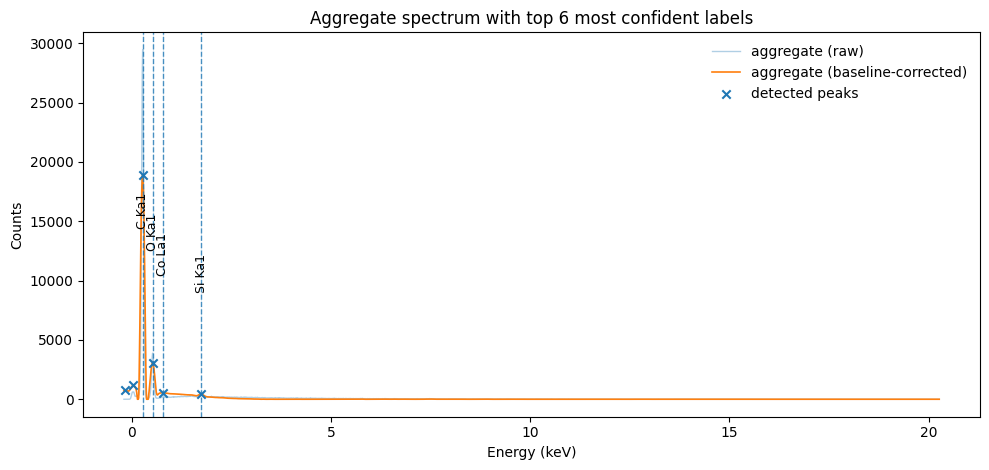


=== margin: cumulative spectrum ===


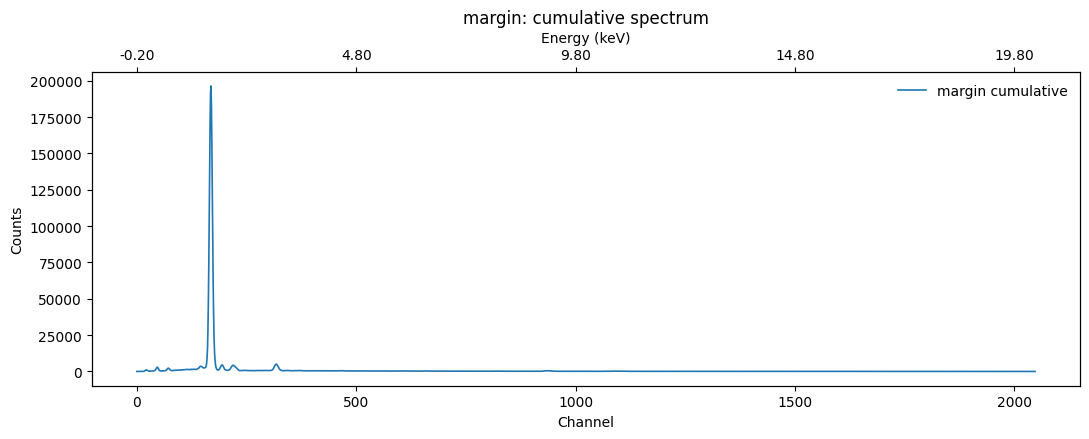

/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


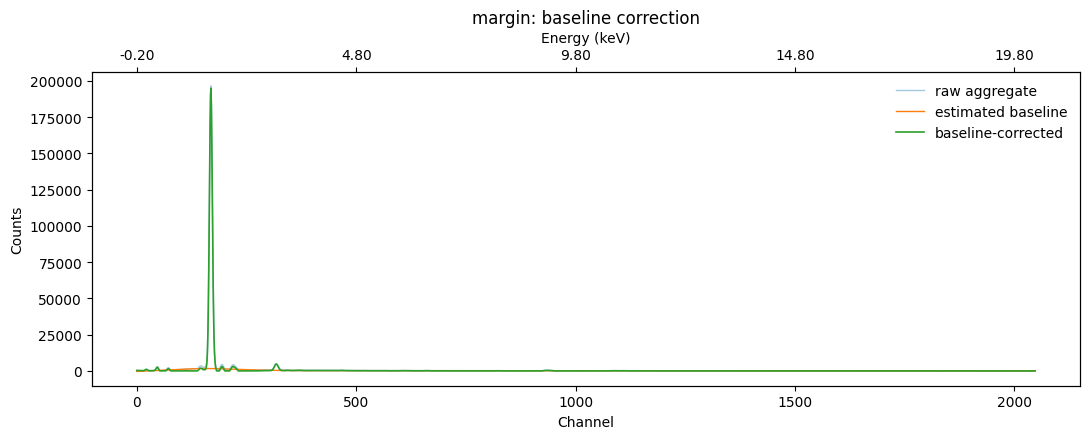

Noise estimate: 1.084403880338288
min_prom: 6.506423282029728
min_height: 3.253211641014864


/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


,x,idx,height,prominence,fwhm,area
0,46.0,46,1959.762130,1711.087345,11.714331,2.077313e+04
1,147.0,147,3239.335204,3239.335204,16.155614,4.359861e+04
2,169.0,169,148098.293392,148098.293392,11.794175,1.512596e+06
3,194.0,194,3684.579920,3039.979681,11.382959,3.905342e+04
4,221.0,221,3910.845665,3632.619545,15.122746,5.047943e+04
5,318.0,318,4054.025768,4054.025768,13.216662,4.509518e+04


/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


,energy_keV,idx,height,prominence,area,fwhm,element,line,lib_energy_keV,delta_keV,label
0,0.262539,46,1959.762130,1711.087345,207.693857,11.714331,C,Ka1,0.27700,0.014461,C Ka1
1,1.272357,147,3239.335204,3239.335204,435.907528,16.155614,Mg,Ka1,1.25379,-0.018567,Mg Ka1
2,1.492317,169,148098.293392,148098.293392,15123.235218,11.794175,Al,Ka1,1.48650,-0.005817,Al Ka1
3,1.742272,194,3684.579920,3039.979681,390.463877,11.382959,Si,Ka1,1.73980,-0.002472,Si Ka1
4,2.012223,221,3910.845665,3632.619545,504.703335,15.122746,P,Ka1,2.01050,-0.001723,P Ka1
5,2.982049,318,4054.025768,4054.025768,450.870588,13.216662,Ag,La1,2.98270,0.000651,Ag La1


/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


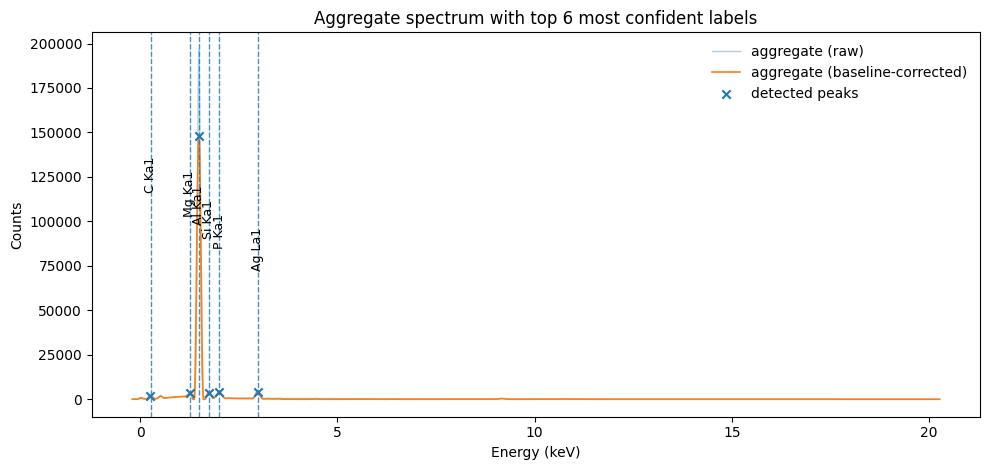


=== sample-corner: cumulative spectrum ===


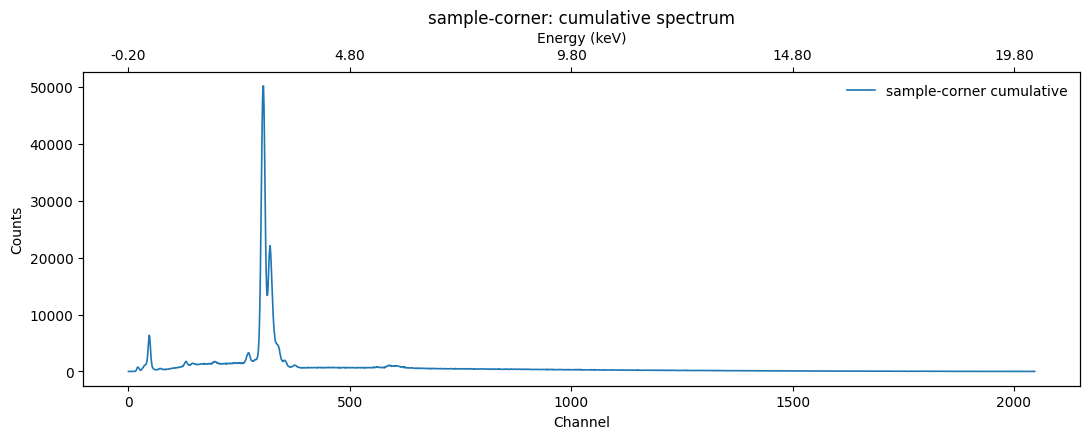

/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


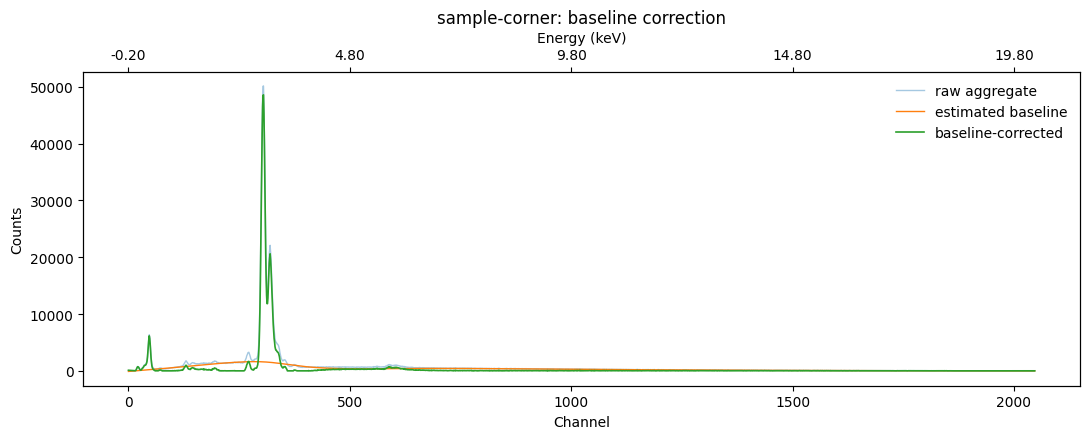

Noise estimate: 1.4906354269825655
min_prom: 8.943812561895392
min_height: 4.471906280947696


/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


,x,idx,height,prominence,fwhm,area
0,47.0,47,4138.321080,4089.324643,12.430157,43665.701540
1,130.0,130,724.671714,724.671714,14.988642,8913.447063
2,271.0,271,1349.277393,1349.277393,12.063040,13842.804699
3,304.0,304,40880.350678,40880.350678,13.664547,456860.036094
4,321.0,321,16969.458124,2115.219437,4.805301,98504.287044
5,589.0,589,628.098623,628.098623,45.557429,23103.075818


/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


,energy_keV,idx,height,prominence,area,fwhm,element,line,lib_energy_keV,delta_keV,label
0,0.272537,47,4138.321080,4089.324643,436.578352,12.430157,C,Ka1,0.2770,0.004463,C Ka1
1,1.102387,130,724.671714,724.671714,89.118413,14.988642,Na,Ka1,1.0403,-0.062087,Na Ka1
2,2.512133,271,1349.277393,1349.277393,138.403109,12.063040,S,Kb1,2.4650,-0.047133,S Kb1
3,2.842074,304,40880.350678,40880.350678,4567.777332,13.664547,Pd,La1,2.8378,-0.004274,Pd La1
4,3.012043,321,16969.458124,2115.219437,984.865416,4.805301,Pd,Lb1,2.9895,-0.022543,Pd Lb1


/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


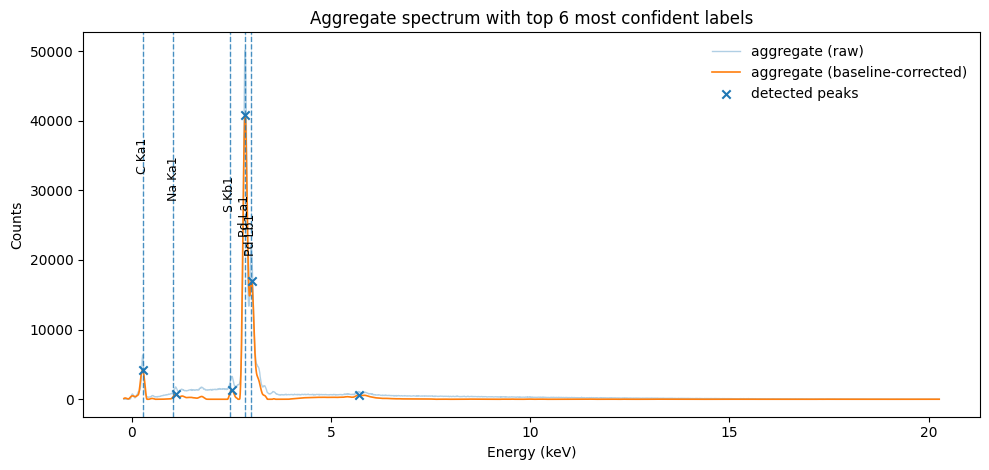

In [35]:
# Condition each aggregate spectrum, detect peaks, and print first-pass element assignments.

peak_summary = {}

for name, res in aggregate_results.items():
    print(f"\n=== {name}: cumulative spectrum ===")
    cum = np.asarray(res["cumulative"], dtype=float)
    x = np.arange(len(cum))

    # Plot raw cumulative spectrum with channel axis and optional energy top axis
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(x, cum, lw=1.2, label=f"{name} cumulative")
    ax.set_xlabel("Channel")
    ax.set_ylabel("Counts")
    ax.set_title(f"{name}: cumulative spectrum")
    if SHOW_ENERGY_TOP_AXIS and cal is not None:
        add_energy_top_axis(ax, cal=cal, n=len(cum))
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()

    # Baseline/corrected view (same spirit as the demo notebook)
    baseline = baseline_als(cum)
    corrected = np.clip(cum - baseline, 0, None)

    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(x, cum, lw=1.0, alpha=0.4, label="raw aggregate")
    ax.plot(x, baseline, lw=1.0, label="estimated baseline")
    ax.plot(x, corrected, lw=1.2, label="baseline-corrected")
    ax.set_xlabel("Channel")
    ax.set_ylabel("Counts")
    ax.set_title(f"{name}: baseline correction")
    if SHOW_ENERGY_TOP_AXIS and cal is not None:
        add_energy_top_axis(ax, cal=cal, n=len(cum))
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()

    # Peak detection table
    peaks_df, meta = detect_peaks(cum, x=x, max_peaks=PEAK_MAX_PEAKS)
    print("Noise estimate:", meta["noise"])
    print("min_prom:", meta["min_prom"])
    print("min_height:", meta["min_height"])
    display(peaks_df)

    # Plot corrected spectrum with peaks marked
    # fig, ax = plt.subplots(figsize=(11, 4.5))
    # ax.plot(x, corrected, label="cumulative (corrected)")
    # if not peaks_df.empty:
    #     ax.scatter(peaks_df["x"], corrected[peaks_df["idx"]], marker="x", label="peaks")
    # ax.set_xlabel("Channel")
    # ax.set_ylabel("Counts (baseline-corrected)")
    # ax.set_title(f"{name}: peak finding")
    # if SHOW_ENERGY_TOP_AXIS and cal is not None:
    #     add_energy_top_axis(ax, cal=cal, n=len(cum))
    # ax.legend(frameon=False)
    # fig.tight_layout()
    # plt.show()

    assign_df = pd.DataFrame()
    lines_df = pd.DataFrame()
    if cal is not None:
        x_keV = make_energy_axis(cum, cal)
        assign_df, peaks_df_id, lines_df, meta_id = identify_elements(
            cum,
            x_keV=x_keV,
            beam_keV=PEAK_BEAM_KEV,
            fwhm_Mn_eV=PEAK_FWHM_MN_EV,
            max_peaks=PEAK_MAX_PEAKS,
        )
        display(assign_df.head(30))
        _ = plot_identified_elements_confident(
            cum,
            res["api_url"],
            assign_df,
            peaks_df=peaks_df_id,
            top_n_labels=PEAK_TOP_N_LABELS,
            fwhm_Mn_eV=PEAK_FWHM_MN_EV,
            show_all_markers=True,
        )
    else:
        print("Skipping element identification because no energy calibration is available.")

    peak_summary[name] = {
        "peaks_df": peaks_df,
        "assign_df": assign_df,
        "lines_df": lines_df,
        "meta": meta,
    }


*Step 3: Choose a spectral band and compare band-sum distributions.*

## 3. Choose a spectral band and then create band-sum histograms


In [62]:
# Define the spectral band to use for band-sum histograms and overlays.

# Band definition for band-sum histograms / overlays.
# BAND_MODE can be "channels" or "keV".
BAND_MODE = "kev" #"channels"
BAND_START = 4.8 #500
BAND_END = 9.8 #1000

HIST_BINS = 500

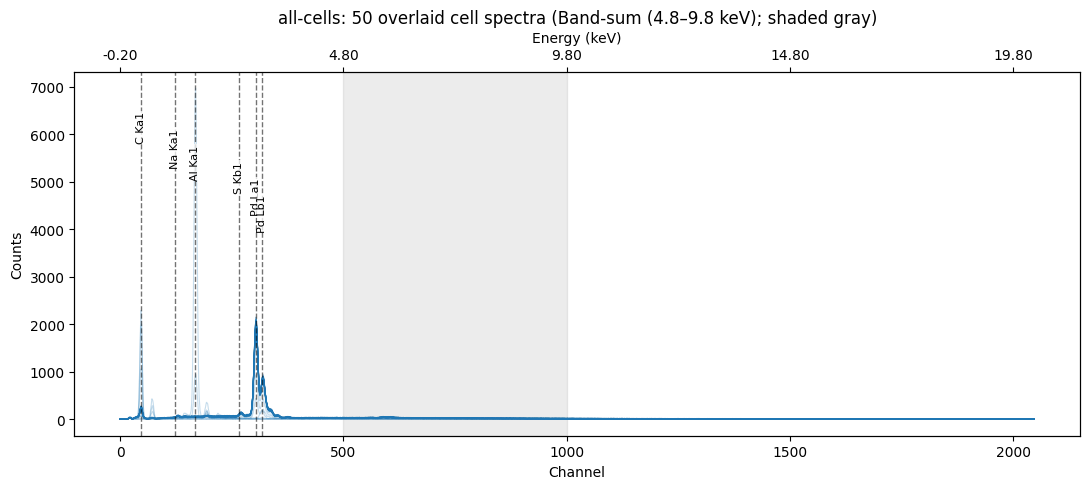

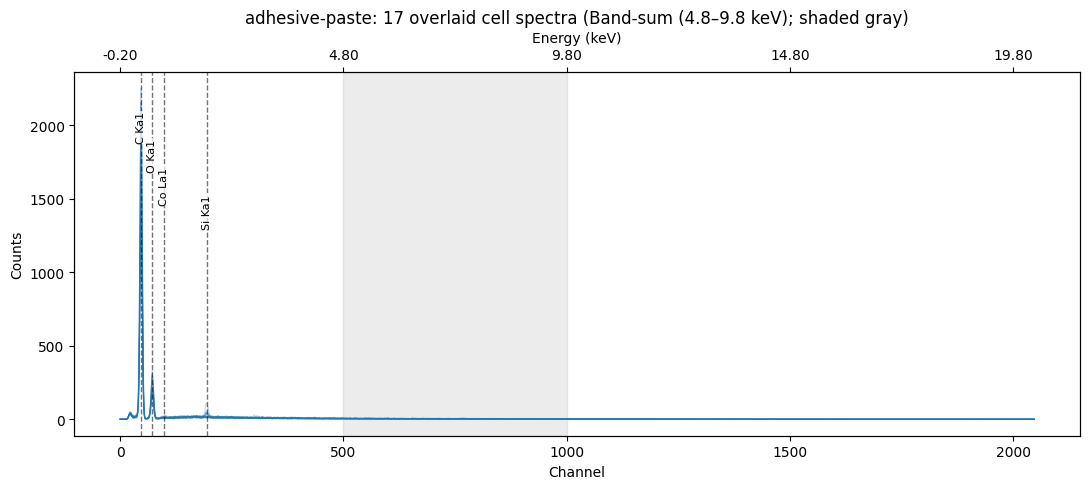

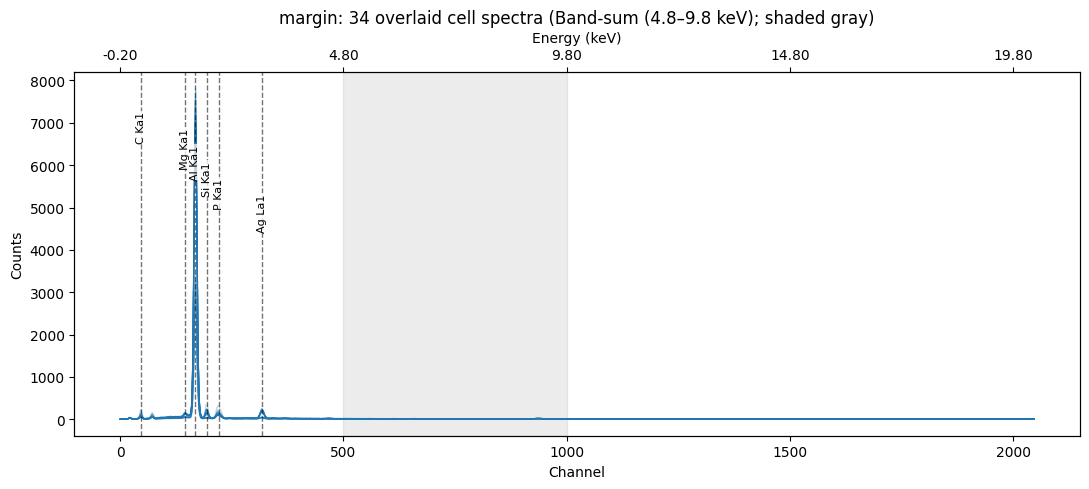

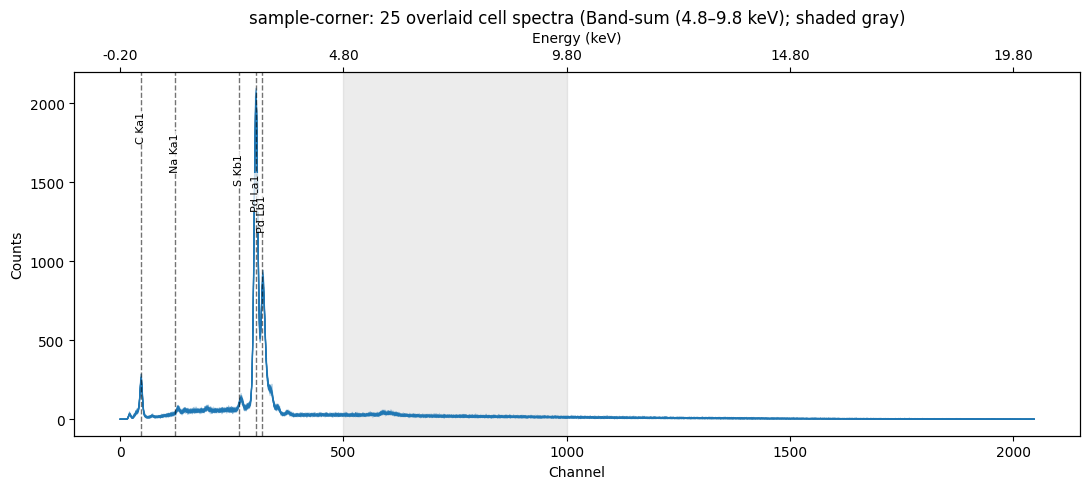

In [63]:
# Overlay up to 50 individual cell spectra per region, with element annotations and the selected band shaded in gray.

N_OVERLAY_SPECTRA = 50

plot_overlaid_cell_spectra(
    aggregate_results=aggregate_results,
    peak_summary=peak_summary,
    band_start=BAND_START,
    band_end=BAND_END,
    band_mode=BAND_MODE,
    cal=cal,
    show_energy_top_axis=SHOW_ENERGY_TOP_AXIS,
    n_overlay_spectra=N_OVERLAY_SPECTRA,
    peak_top_n_labels=PEAK_TOP_N_LABELS,
    peak_fwhm_mn_ev=PEAK_FWHM_MN_EV,
    show_peak_crosses=False,
    show_element_lines=True,
    band_color="gray",
    band_alpha=0.15,
)

In [64]:
# Resolve the requested band to channel indices and compute per-cell band sums.

band_start_ch, band_end_ch = resolve_band_to_channels(
    BAND_START,
    BAND_END,
    band_mode=BAND_MODE,
    cal=cal,
)

print(f"Resolved analysis band: {band_start_ch}–{band_end_ch} channels")
if str(BAND_MODE).lower() == "kev":
    print(f"Requested in energy units: {BAND_START}–{BAND_END} keV")

if cal is not None:
    band_lo_keV = channel_to_keV(band_start_ch, cal)
    band_hi_keV = channel_to_keV(band_end_ch, cal)
    source_text = "config.txt" if cal.get("from_config") else "defaults"
    print(f"Resolved energy span: {band_lo_keV:.3f}–{band_hi_keV:.3f} keV ({source_text})")

for name, res in aggregate_results.items():
    res["df"] = res["df"].copy()
    res["df"]["band_value"] = res["df"]["spectrum"].apply(lambda s: band_sum(s, band_start_ch, band_end_ch))

Resolved analysis band: 500–1000 channels
Requested in energy units: 4.8–9.8 keV
Resolved energy span: 4.802–9.801 keV (config.txt)


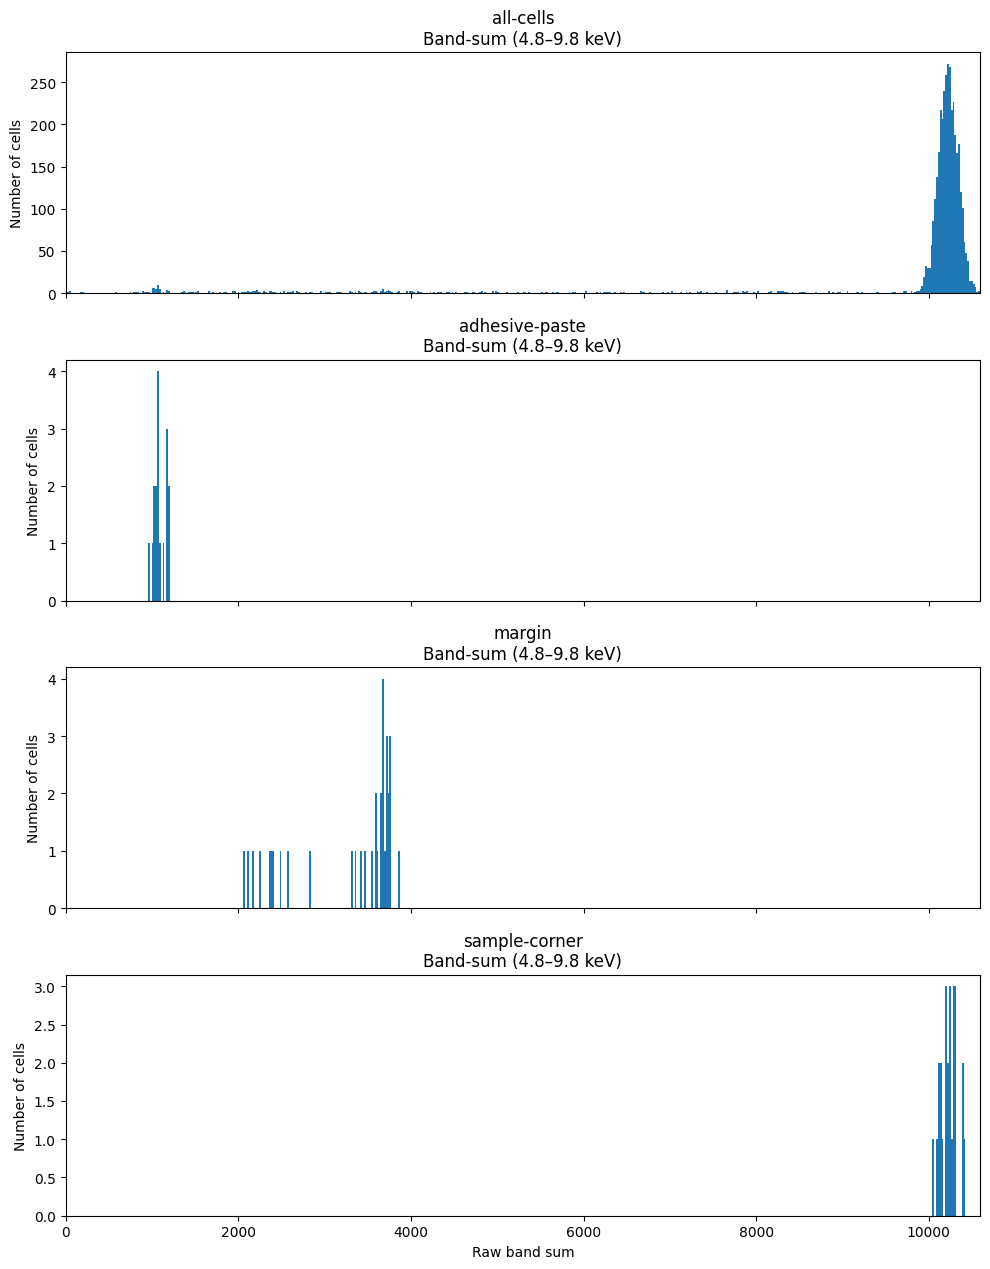

In [65]:
# Build vertically stacked histograms with shared bins and a shared global x-axis range.

# Shared bins across all aggregates
all_band_vals = np.concatenate([
    res["df"]["band_value"].dropna().to_numpy(dtype=float)
    for res in aggregate_results.values()
    if len(res["df"]) > 0
])

global_min = float(np.min(all_band_vals))
global_max = float(np.max(all_band_vals))

if global_max > global_min:
    shared_bins = np.linspace(global_min, global_max, HIST_BINS + 1)
else:
    shared_bins = np.array([global_min - 0.5, global_max + 0.5])

n = len(aggregate_results)

fig, axes = plt.subplots(
    n, 1,
    figsize=(10, 3.2 * n),
    sharex=True,
    squeeze=False
)
axes = axes[:, 0]

for i, (ax, (name, res)) in enumerate(zip(axes, aggregate_results.items())):
    vals = res["df"]["band_value"].dropna().to_numpy(dtype=float)
    ax.hist(vals, bins=shared_bins)

    ax.set_xlim(global_min, global_max)
    ax.set_ylabel("Number of cells")
    ax.set_title(f"{name}\n{band_label_text(BAND_START, BAND_END, BAND_MODE)}")

    if i < n - 1:
        ax.tick_params(axis="x", labelbottom=False)

axes[-1].set_xlabel("Raw band sum")

plt.tight_layout()
plt.show()

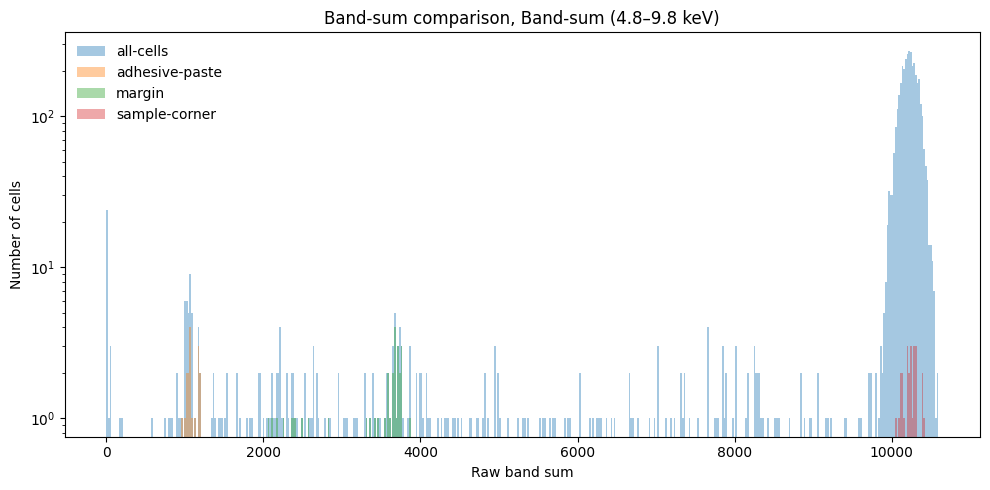

In [66]:
# Overlay all band-sum histograms on one log-scale plot for direct comparison.

plt.figure(figsize=(10, 5))

for name, res in aggregate_results.items():
    vals = res["df"]["band_value"].dropna().to_numpy(dtype=float)
    plt.hist(vals, bins=shared_bins, alpha=0.40, label=name)

plt.yscale("log")
plt.xlabel("Raw band sum")
plt.ylabel("Number of cells")
plt.title(f"Band-sum comparison, {band_label_text(BAND_START, BAND_END, BAND_MODE)}")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [67]:
# Summarize the band-sum distributions and propose value ranges for overlays.

stats_rows = []

for name, res in aggregate_results.items():
    stats = summarize_band_values(res["df"]["band_value"])
    stats["roi_name"] = name
    stats_rows.append(stats)

stats_df = pd.DataFrame(stats_rows).set_index("roi_name")

range_suggestions_df = pd.DataFrame({
    "global_min": int(round(global_min)),
    "global_max": int(round(global_max)),
    "vmin_mild": stats_df["p05"].round().astype(int),
    "vmax_mild": stats_df["p95"].round().astype(int),
    "vmin_strong": stats_df["p10"].round().astype(int),
    "vmax_strong": stats_df["p90"].round().astype(int),
    "threshold_candidate": stats_df["p10"].round().astype(int),
}, index=stats_df.index)

display(stats_df.round(3))
display(range_suggestions_df)

,n,min,p01,p05,p10,p25,p50,p75,p90,p95,p99,max,mean,std
roi_name,,,,,,,,,,,,,,
all-cells,3861,0.0,963.60,4046.00,9975.0,10120.00,10211.0,10295.00,10364.0,10403.0,10481.80,10593.0,9699.125,1927.276
adhesive-paste,17,974.0,979.28,1000.40,1017.8,1056.00,1076.0,1168.00,1182.8,1188.6,1193.72,1195.0,1091.353,67.051
margin,34,2064.0,2077.20,2151.45,2285.9,2630.75,3607.5,3711.75,3751.5,3759.4,3828.33,3861.0,3266.882,603.930
sample-corner,25,10043.0,10057.64,10106.40,10116.4,10159.00,10239.0,10296.00,10361.6,10394.8,10412.48,10418.0,10233.840,94.382


,global_min,global_max,vmin_mild,vmax_mild,vmin_strong,vmax_strong,threshold_candidate
roi_name,,,,,,,
all-cells,0,10593,4046,10403,9975,10364,9975
adhesive-paste,0,10593,1000,1189,1018,1183,1018
margin,0,10593,2151,3759,2286,3752,2286
sample-corner,0,10593,10106,10395,10116,10362,10116


*Step 4: Optionally create or delete overlay heatmap files in the Surface Viewer.*

## 4. Optional: create overlay heatmap files


In [83]:
range_suggestions_df["global_max"].iloc[0]

np.int64(10593)

In [87]:
# Choose the display range to apply when creating the overlay heatmap.

# Pick one of the suggested ranges from range_suggestions_df above, then edit if desired.
VMIN = range_suggestions_df["global_min"].iloc[0]
VMAX = range_suggestions_df["global_max"].iloc[0]

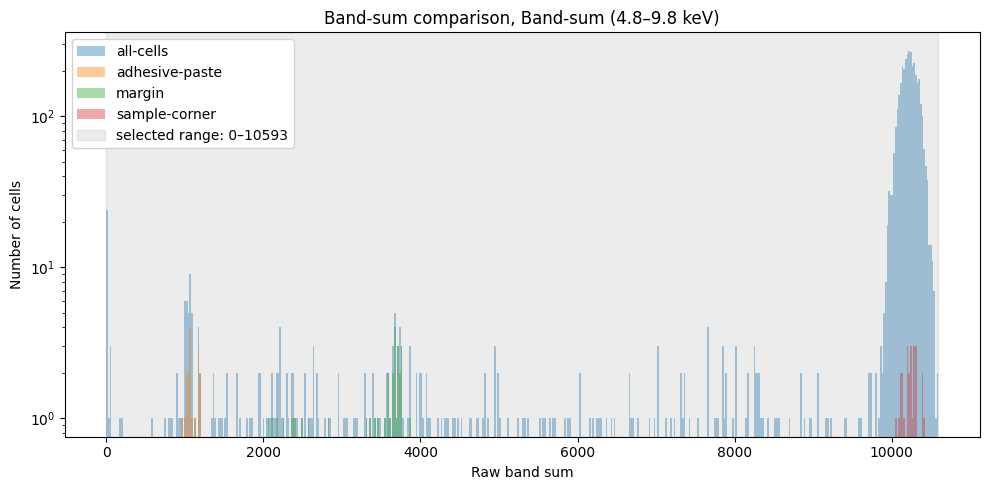

In [88]:
# Preview the chosen overlay range on the combined log-scale band-sum histogram.

plt.figure(figsize=(10, 5))

for name, res in aggregate_results.items():
    vals = res["df"]["band_value"].dropna().to_numpy(dtype=float)
    plt.hist(vals, bins=shared_bins, alpha=0.40, label=name)

plt.axvspan(VMIN, VMAX, color="gray", alpha=0.15, label=f"selected range: {VMIN}–{VMAX}")

plt.yscale("log")
plt.xlabel("Raw band sum")
plt.ylabel("Number of cells")
plt.title(f"Band-sum comparison, {band_label_text(BAND_START, BAND_END, BAND_MODE)}")
plt.legend(frameon=True, facecolor="white", framealpha=1.0, edgecolor="lightgray", loc="upper left")
plt.tight_layout()
plt.show()

In [89]:
# Authenticate to the overlay API and extract dataset metadata from the ROI URL.

auth = get_api_auth()

dataset = parse_qs(urlparse(ROI_API_URLS[0]).query)["dataset"][0]
input_folder = "aggregated-spectra"

print("Dataset:", dataset)
print("Input folder:", input_folder)
print(f"Using resolved band: {band_start_ch}–{band_end_ch} channels")

API username: ··········
API password: ··········
Dataset: JPB2_Pd-TF-12_EDS_post (20250826 # 10 after (eds))
Input folder: aggregated-spectra
Using resolved band: 500–1000 channels


In [91]:
# Create the overlay heatmap and print both the overlay URL and the sample viewer link.

resp_create = create_overlay(
    auth=auth,
    dataset=dataset,
    input_folder=input_folder,
    band_start=band_start_ch,
    band_end=band_end_ch,
    vmin=VMIN,
    vmax=VMAX,
)

overlay_file = resp_create["output_file"]
print("Created:", overlay_file)
print("URL:", resp_create["output_url"])

sample_viewer_url = f"https://nucleonics.mit.edu/surface-viewer/?dataset={quote_plus(dataset)}"
resp_create["sample_viewer_url"] = sample_viewer_url
print("Sample viewer:", sample_viewer_url)


Status: 200
{'ok': True, 'action': 'create', 'dataset': 'JPB2_Pd-TF-12_EDS_post (20250826 # 10 after (eds))', 'input_folder': 'aggregated-spectra', 'output_file': 'overlays/heatmap_ch500-1000_rng0-10593.json', 'output_url': 'https://nucleonics.mit.edu/surface-viewer/data/JPB2_Pd-TF-12_EDS_post%20%2820250826%20%23%2010%20after%20%28eds%29%29/overlays/heatmap_ch500-1000_rng0-10593.json', 'output_exists': True, 'dry_run': False, 'stdout': 'Wrote 3861 rectangles → /home/lenr/proxy-server/surface-viewer/data/JPB2_Pd-TF-12_EDS_post (20250826 # 10 after (eds))/overlays/heatmap_ch500-1000_rng0-10593.json\n', 'stderr': ''}
Created: overlays/heatmap_ch500-1000_rng0-10593.json
URL: https://nucleonics.mit.edu/surface-viewer/data/JPB2_Pd-TF-12_EDS_post%20%2820250826%20%23%2010%20after%20%28eds%29%29/overlays/heatmap_ch500-1000_rng0-10593.json
Sample viewer: https://nucleonics.mit.edu/surface-viewer/?dataset=JPB2_Pd-TF-12_EDS_post+%2820250826+%23+10+after+%28eds%29%29


In [92]:
# Show the current overlay filename for quick reuse or copy/paste.

overlay_file

'overlays/heatmap_ch500-1000_rng0-10593.json'

In [96]:
# Specify an overlay filename if you want to delete an existing overlay.

overlay_file_to_be_deleted = "overlays/heatmap_ch500-1000_rng0-11262.json"  # replace with the file you want to delete

In [97]:
# # Delete the selected overlay heatmap file from the server.

resp_delete = delete_overlay(
    auth=auth,
    dataset=dataset,
    overlay_file=overlay_file_to_be_deleted,
)

Status: 200
{'ok': True, 'action': 'delete', 'dataset': 'JPB2_Pd-TF-12_EDS_post (20250826 # 10 after (eds))', 'output_file': 'overlays/heatmap_ch500-1000_rng0-11262.json', 'output_url': 'https://nucleonics.mit.edu/surface-viewer/data/JPB2_Pd-TF-12_EDS_post%20%2820250826%20%23%2010%20after%20%28eds%29%29/overlays/heatmap_ch500-1000_rng0-11262.json', 'deleted': True}
